Assignment-1: Linear Regression Model
Objective
To build a Linear Regression model using the HR Attrition dataset. The target variable is Attrition. Maximum 8 input features are used.

Dataset Description
The dataset contains employee information such as:

Age
Monthly Income
Years at Company
Job Satisfaction
Distance from Home
Education
Work Life Balance
Performance Rating
Attrition (Target Column)

Goal
To predict employee attrition using Linear Regression and evaluate the model using:

Mean Squared Error (MSE)
R² Score


Residual Sum of Squares (RSS): 193.710976630422


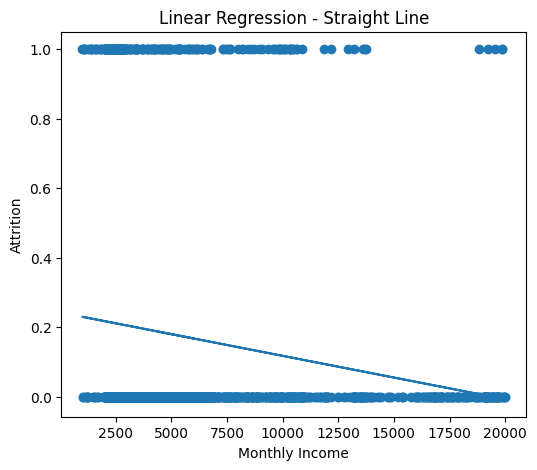

In [1]:

# ============================================
# Linear Regression (Single Feature)
# Straight Line + RSS Calculation
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1️⃣ Load Dataset
df = pd.read_csv(r"C:\Users\vikram sahani\Desktop\WA_Fn-UseC_-HR-Employee-Attrition.csv")

# 2️⃣ Convert Attrition to numeric
df["Attrition"] = df["Attrition"].map({"Yes":1, "No":0})

# 3️⃣ Take Only One Feature for Straight Line
X = df[["MonthlyIncome"]]   # Single independent variable
y = df["Attrition"]         # Dependent variable

# 4️⃣ Create Model
model = LinearRegression()
model.fit(X, y)

# 5️⃣ Predictions
y_pred = model.predict(X)

# 6️⃣ Calculate RSS (Residual Sum of Squares)
rss = np.sum((y - y_pred) ** 2)
print("Residual Sum of Squares (RSS):", rss)

# 7️⃣ Plot Straight Line
plt.figure(figsize=(6,5))
plt.scatter(X, y)                # Actual points
plt.plot(X, y_pred)              # Regression straight line
plt.xlabel("Monthly Income")
plt.ylabel("Attrition")
plt.title("Linear Regression - Straight Line")
plt.show()


Mean Squared Error (MSE): 0.10878228022324335
R2 Score: 0.0545293943311953

Feature Coefficients:
             Feature  Coefficient
0                Age    -0.003970
1      MonthlyIncome    -0.000006
2     YearsAtCompany    -0.003817
3    JobSatisfaction    -0.037738
4   DistanceFromHome     0.003044
5          Education     0.004046
6    WorkLifeBalance    -0.036714
7  PerformanceRating    -0.009828


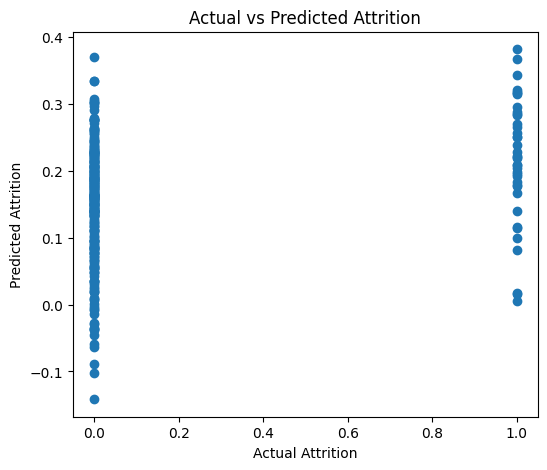

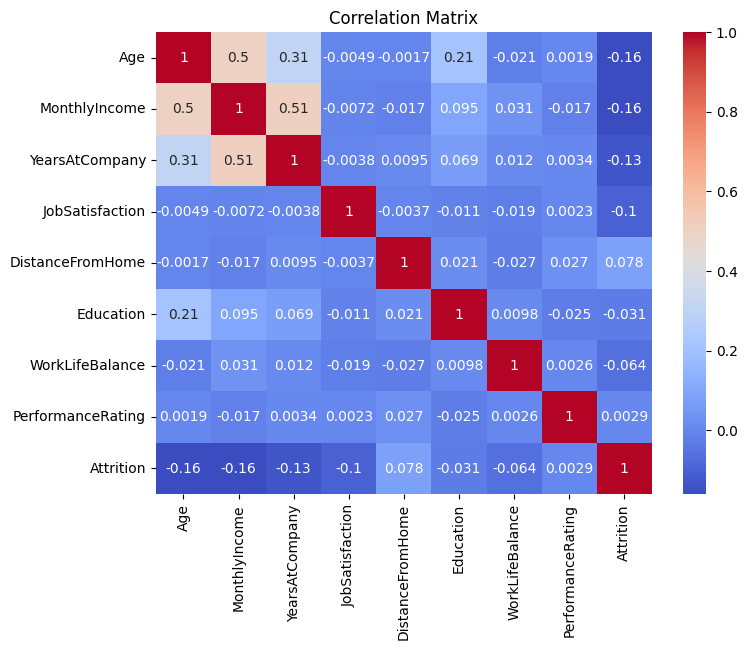

In [3]:
# =====================================================
# Assignment-1 : Linear Regression (Attrition Dataset)
# =====================================================

# 1️⃣ Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 2️⃣ Load Dataset
df = pd.read_csv(r"C:\Users\vikram sahani\Desktop\WA_Fn-UseC_-HR-Employee-Attrition.csv")

# 3️⃣ Convert Target Column (Yes/No → 1/0)
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

# 4️⃣ Select Maximum 8 Input Features
X = df[[
    "Age",
    "MonthlyIncome",
    "YearsAtCompany",
    "JobSatisfaction",
    "DistanceFromHome",
    "Education",
    "WorkLifeBalance",
    "PerformanceRating"
]]

# 5️⃣ Define Output
y = df["Attrition"]

# 6️⃣ Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7️⃣ Build Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 8️⃣ Predictions
y_pred = model.predict(X_test)

# 9️⃣ Model Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)

# 🔟 Feature Coefficients
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nFeature Coefficients:")
print(coeff_df)

# 1️⃣1️⃣ Visualization - Actual vs Predicted
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Attrition")
plt.ylabel("Predicted Attrition")
plt.title("Actual vs Predicted Attrition")
plt.show()

# 1️⃣2️⃣ Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[X.columns.tolist() + ["Attrition"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# =====================================================
# End of Assignment-1
# =====================================================